In [1]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torch.utils.data import random_split, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm.notebook import tqdm
import numpy as np
import random
from torchvision.models import resnet18, ResNet18_Weights

def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(seed=42)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'device: {device}')

device: cuda


In [2]:
# transform=None → otteniamo le immagini PIL grezze, il transform lo gestiamo noi dopo
base_trainval = torchvision.datasets.FGVCAircraft(
    root='./data', split='trainval', annotation_level='variant',
    download=True, transform=None)

base_test = torchvision.datasets.FGVCAircraft(
    root='./data', split='test', annotation_level='variant',
    download=True, transform=None)

print(f"Immagini trainval: {len(base_trainval)} - test: {len(base_test)}")

100%|██████████| 2.75G/2.75G [01:48<00:00, 25.4MB/s]


Immagini trainval: 6667 - test: 3333


AttributeError: 'Image' object has no attribute 'permute'

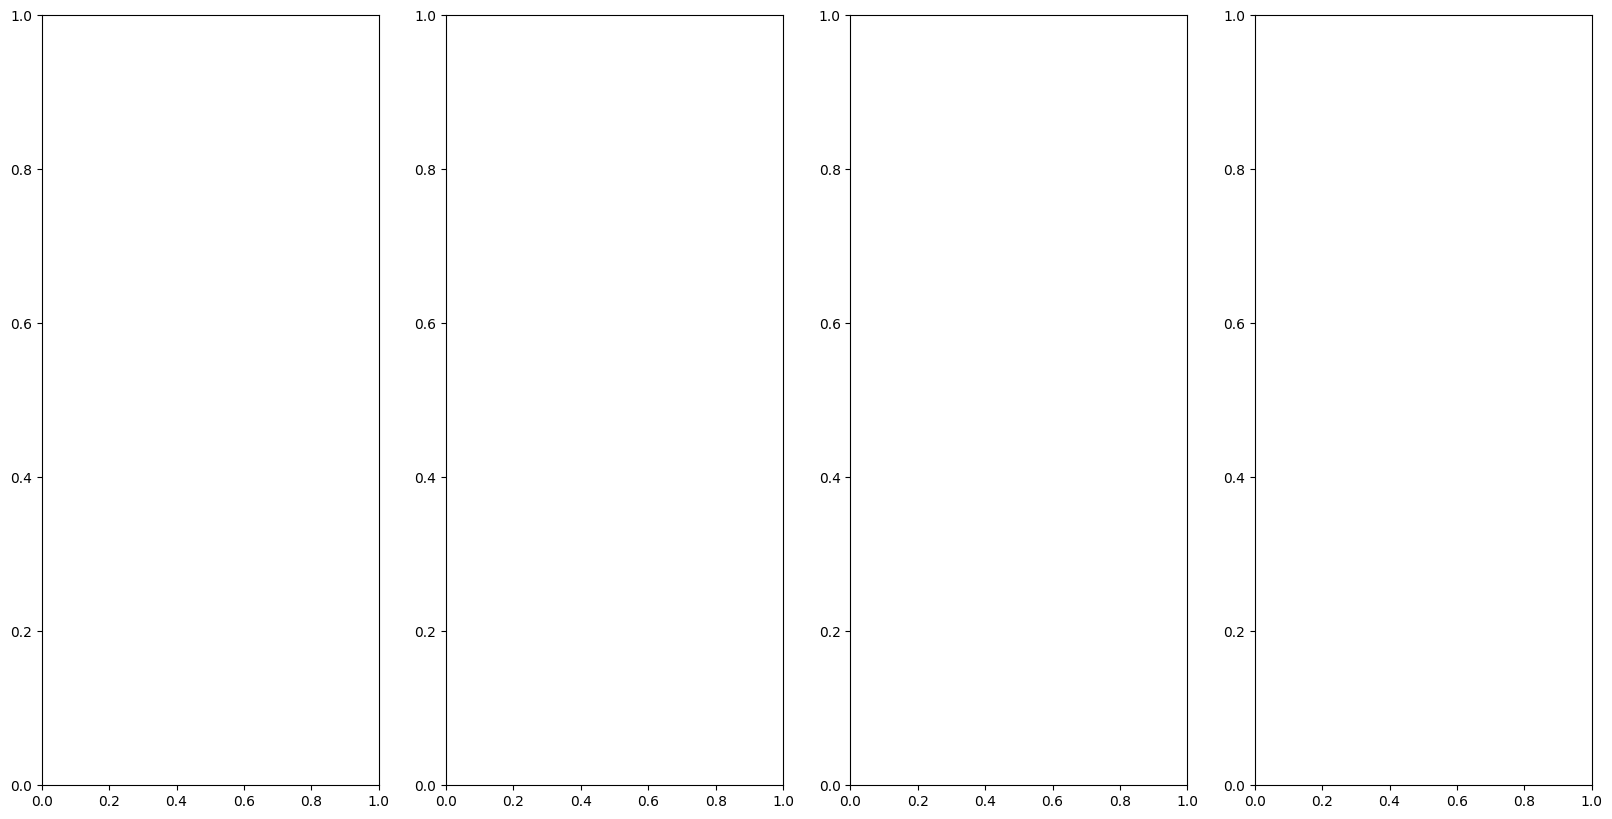

In [3]:
_, ax = plt.subplots(1, 4, figsize=(20, 10))
class_names = base_trainval.classes

for i, idx in enumerate([0, 50, 100, 200]):
    img, label = base_trainval[idx]
    ax[i].imshow(img.permute(1, 2, 0))
    ax[i].set_title(class_names[label])
    ax[i].axis("off")

In [4]:
print(len(class_names))

100


In [5]:
val_split = 0.2
n = len(base_trainval)
val_size = int(n * val_split)

g = torch.Generator().manual_seed(42)
perm = torch.randperm(n, generator=g).tolist()

val_indices   = perm[:val_size]
train_indices = perm[val_size:]

print(f"Training: {len(train_indices)} - Validation: {len(val_indices)}")

Training: 5334 - Validation: 1333


In [7]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])

# LENTO e deterministico → applicato UNA volta sola e messo in cache
pre_resize = transforms.Resize((146, 146))

# LEGGERO e casuale → applicato a ogni epoca (l'augmentation deve restare viva)
train_aug = transforms.Compose([
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize,
    # transforms.RandomErasing(p=0.25),
])

# augmentation completa (con erasing) — il nuovo default
train_aug_full = transforms.Compose([
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.25),
])

# Valutazione: deterministica
eval_aug = transforms.Compose([
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    normalize,
])

In [8]:
class CachedAircraft(Dataset):
    def __init__(self, base, indices, pre, aug):
        self.aug = aug
        self.cache = []
        for i in tqdm(indices, desc="caching"):
            img, label = base[i]
            self.cache.append((pre(img), label))

    def set_aug(self, aug):
        self.aug = aug

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        img, label = self.cache[idx]
        return self.aug(img), label

In [9]:
train_ds = CachedAircraft(base_trainval, train_indices, pre_resize, train_aug)
val_ds   = CachedAircraft(base_trainval, val_indices,   pre_resize, eval_aug)
test_ds  = CachedAircraft(base_test, list(range(len(base_test))), pre_resize, eval_aug)

batch_size = 128
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=batch_size, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=batch_size, num_workers=2)

caching:   0%|          | 0/5334 [00:00<?, ?it/s]

caching:   0%|          | 0/1333 [00:00<?, ?it/s]

caching:   0%|          | 0/3333 [00:00<?, ?it/s]

In [ ]:
import time
t = time.time()
for imgs, labels in train_dl:
    imgs = imgs.to(device)
print(f"Solo data loading: {time.time()-t:.1f}s")

Solo data loading: 5.6s


In [25]:
import torch.nn as nn
import torch
"""
class SimpleAircraftCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()

        # 1. BLOCCO DI ESTRAZIONE DELLE FEATURE (CNN)
        self.features = nn.Sequential(
            # Blocco 1
            # Input: 3 canali (RGB), Output: 16 filtri. kernel_size 3x3 è lo standard.
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Dimezza le dimensioni spaziali (224 -> 112)

            # Blocco 2
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Dimezza ancora (112 -> 56)

            # Blocco 3
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Dimezza ancora (56 -> 28)
        )

        # 2. BLOCCO DI CLASSIFICAZIONE (MLP)
        self.classifier = nn.Sequential(
            nn.Flatten(), # Appiattisce il tensore per darlo in pasto ai layer lineari

            # ATTENZIONE AL CALCOLO QUI SOTTO: 64 canali * 28 altezza * 28 larghezza
            nn.Linear(64 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Spegne il 50% dei neuroni a caso per combattere l'overfitting
            nn.Linear(512, num_classes) # Output finale: 100 classi
        )

    def forward(self, x):
        x = self.features(x)    # Passa per le convoluzioni
        x = self.classifier(x)  # Passa per i layer lineari finali
        return x
"""

class SimpleAircraftCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),    nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                                          # 128 -> 64
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 64 -> 32
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 32 -> 16
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 16 -> 8
            nn.AdaptiveAvgPool2d((1, 1)),                            # -> 512 x 1 x 1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

In [26]:
model = SimpleAircraftCNN(num_classes=100).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0) # , weight_decay=5e-4

In [27]:
def ncorrect(scores, y):
    y_hat = torch.argmax(scores, -1)
    return (y_hat == y).sum()

def accuracy(scores, y):
    correct = ncorrect(scores, y)
    return correct.true_divide(y.shape[0])

def train_loop(model, train_dl, epochs, opt, val_dl=None, scheduler=None, verbose=False, label_smoothing=None):
    best_val_acc = 0
    best_train = 0
    best_params = []
    best_epoch = -1

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for e in tqdm(range(epochs)):
        model.train()
        train_loss = 0
        train_samples = 0
        train_acc = 0
        for train_data in train_dl:
            imgs = train_data[0].to(device)
            labels = train_data[1].to(device)
            scores = model(imgs)
            loss = F.cross_entropy(scores, labels, reduction="sum", label_smoothing=label_smoothing)
            train_loss += loss.item()
            train_samples += imgs.shape[0]
            train_acc += ncorrect(scores, labels).item()

            opt.zero_grad()
            loss.backward()
            opt.step()

        train_acc /= train_samples
        train_loss /= train_samples

        model.eval()
        with torch.no_grad():
            val_loss = 0
            val_samples = 0
            val_acc = 0
            if val_dl is not None:
                for val_data in val_dl:
                    imgs = val_data[0].to(device)
                    labels = val_data[1].to(device)
                    val_scores = model(imgs)
                    val_loss += F.cross_entropy(val_scores, labels, reduction="sum", label_smoothing=label_smoothing).item()
                    val_samples += imgs.shape[0]
                    val_acc += ncorrect(val_scores, labels).item()
                val_acc /= val_samples
                val_loss /= val_samples

            if val_dl is None or val_acc > best_val_acc:
                best_val_acc = val_acc if val_dl is not None else 0
                best_train = train_acc
                best_params = model.state_dict()
                torch.save(best_params, "best_model.pth")
                best_epoch = e

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss if val_dl is not None else None)
        history["val_acc"].append(val_acc if val_dl is not None else None)

        if verbose and e % 5 == 0:
            tqdm.write(f"Epoch {e}: train loss {train_loss:.3f} - train acc {train_acc:.3f}" + ("" if val_dl is None else f" - valid loss {val_loss:.3f} - valid acc {val_acc:.3f}"))

    if verbose and val_dl is not None:
        tqdm.write(f"Best epoch {best_epoch}, best acc {best_val_acc}, best train {best_train}")

    return best_val_acc, best_params, best_epoch, best_train, history

In [29]:
epochs = 6
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_acc, best_params, best_epoch, best_train, _ = train_loop(
    model,
    train_dl,
    epochs,
    optimizer,
    val_dl,
    scheduler=scheduler,
    verbose=True,
    label_smoothing=0.1)

  0%|          | 0/6 [00:00<?, ?it/s]

Epoch 0: train loss 4.272 - train acc 0.060 - valid loss 4.270 - valid acc 0.071
Epoch 5: train loss 4.267 - train acc 0.059 - valid loss 4.269 - valid acc 0.069
Best epoch 0, best acc 0.07051762940735183, best train 0.06036745406824147


In [57]:
model.load_state_dict(torch.load("best_model.pth"))  # pesi dell'epoca 97
model.eval()

correct = total = 0
with torch.no_grad():
    for imgs, labels in test_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += ncorrect(model(imgs), labels).item()
        total += imgs.shape[0]

print(f"Test accuracy: {correct/total:.4f}")

Test accuracy: 0.5473


### Ablation

In [17]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/ipcv_ablation_results'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [18]:
import json
import pickle

RESULTS_FILE = os.path.join(SAVE_DIR, "ablation_results.json")
HISTORY_DIR = os.path.join(SAVE_DIR, "histories")
os.makedirs(HISTORY_DIR, exist_ok=True)

def load_existing_results():
    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE, "r") as f:
            return json.load(f)
    return {}

def save_result(name, result):
    # separa history (troppo pesante/nested per un json semplice) dal resto
    result_light = {k: v for k, v in result.items() if k != "history"}

    existing = load_existing_results()
    existing[name] = result_light
    with open(RESULTS_FILE, "w") as f:
        json.dump(existing, f, indent=2)

    # salva la history a parte, in pickle (gestisce meglio liste/None)
    with open(os.path.join(HISTORY_DIR, f"{name}.pkl"), "wb") as f:
        pickle.dump(result["history"], f)

    # salva anche i pesi del modello per quella configurazione, se vuoi poterli ricaricare dopo
    # (opzionale, occupa più spazio)

In [11]:
class SimpleAircraftCNN_ablation(nn.Module):
    def __init__(self, num_classes=100, use_bn=True, use_dropout=True, dropout_p=0.5):
        super().__init__()
        def bn(ch):
            return nn.BatchNorm2d(ch) if use_bn else nn.Identity()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),    bn(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),  bn(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), bn(256), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), bn(512), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p) if use_dropout else nn.Identity(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [12]:
def evaluate(model, dl):
  model.eval()
  correct = total = 0
  with torch.no_grad():
      for imgs, labels in dl:
          imgs, labels = imgs.to(device), labels.to(device)
          correct += ncorrect(model(imgs), labels).item()
          total += imgs.shape[0]
  accuracy = correct/total
  return accuracy

In [13]:
BASE_CONFIG = dict(
    use_bn=True, use_dropout=True, dropout_p=0.5,
    use_augmentation=True, use_erasing=True,
    weight_decay=0.0,
    label_smoothing=0.1, use_scheduler=True,
)

ablations = {
    "full_model":        BASE_CONFIG,
    "no_batchnorm":      {**BASE_CONFIG, "use_bn": False},
    "no_dropout":        {**BASE_CONFIG, "use_dropout": False},
    "no_augmentation":   {**BASE_CONFIG, "use_augmentation": False, "use_erasing": False},
    "no_erasing":        {**BASE_CONFIG, "use_erasing": False},
    "no_label_smoothing":{**BASE_CONFIG, "label_smoothing": 0.0},
    "no_scheduler":      {**BASE_CONFIG, "use_scheduler": False},
}

In [14]:
def select_aug(config):
    if not config["use_augmentation"]:
        return eval_aug
    return train_aug_full if config["use_erasing"] else train_aug

In [30]:
def run_ablation(name, config, epochs=100, seed=42):
    torch.manual_seed(seed)

    train_ds.set_aug(select_aug(config))
    train_dl_ab = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)

    model = SimpleAircraftCNN_ablation(
        num_classes=100,
        use_bn=config["use_bn"],
        use_dropout=config["use_dropout"],
        dropout_p=config["dropout_p"],
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,
                                  weight_decay=config["weight_decay"])
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
                 if config["use_scheduler"] else None)

    best_val_acc, best_params, best_epoch, best_train, history = train_loop(
        model, train_dl_ab, epochs, optimizer, val_dl,
        scheduler=scheduler, verbose=False,
        label_smoothing=config["label_smoothing"],
    )

    model.load_state_dict(best_params)
    test_acc = evaluate(model, test_dl)

    # train_ds.set_aug(eval_aug)
    # train_eval_dl = DataLoader(train_ds, batch_size=batch_size, num_workers=2)
    # train_acc_final = evaluate(model, train_eval_dl)

    gap = best_train - test_acc

    return {"name": name, "test_acc": test_acc, "train_acc": best_train,
            "gap": gap, "best_epoch": best_epoch, "history": history}

In [19]:
existing_results = load_existing_results()
results = []

for name, cfg in ablations.items():
    if name in existing_results:
        print(f"[SKIP] '{name}' già completato, carico dal salvataggio.")
        r = existing_results[name]
        with open(os.path.join(HISTORY_DIR, f"{name}.pkl"), "rb") as f:
            r["history"] = pickle.load(f)
        results.append(r)
        continue

    print(f"[RUN] Avvio ablation: {name}")
    r = run_ablation(name, cfg)
    save_result(name, r)
    results.append(r)
    print(f"[DONE] '{name}': test_acc={r['test_acc']:.4f}, gap={r['gap']:.4f}")

[RUN] Avvio ablation: full_model


  0%|          | 0/100 [00:00<?, ?it/s]

[DONE] 'full_model': test_acc=0.5443, gap=0.3564
[RUN] Avvio ablation: no_batchnorm


  0%|          | 0/100 [00:00<?, ?it/s]

[DONE] 'no_batchnorm': test_acc=0.4095, gap=0.3376
[RUN] Avvio ablation: no_dropout


...

[DONE] 'no_dropout': test_acc=0.5344, gap=0.4576
[RUN] Avvio ablation: no_augmentation


  0%|          | 0/100 [00:00<?, ?it/s]

[DONE] 'no_augmentation': test_acc=0.4986, gap=0.5014
[RUN] Avvio ablation: no_erasing


  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

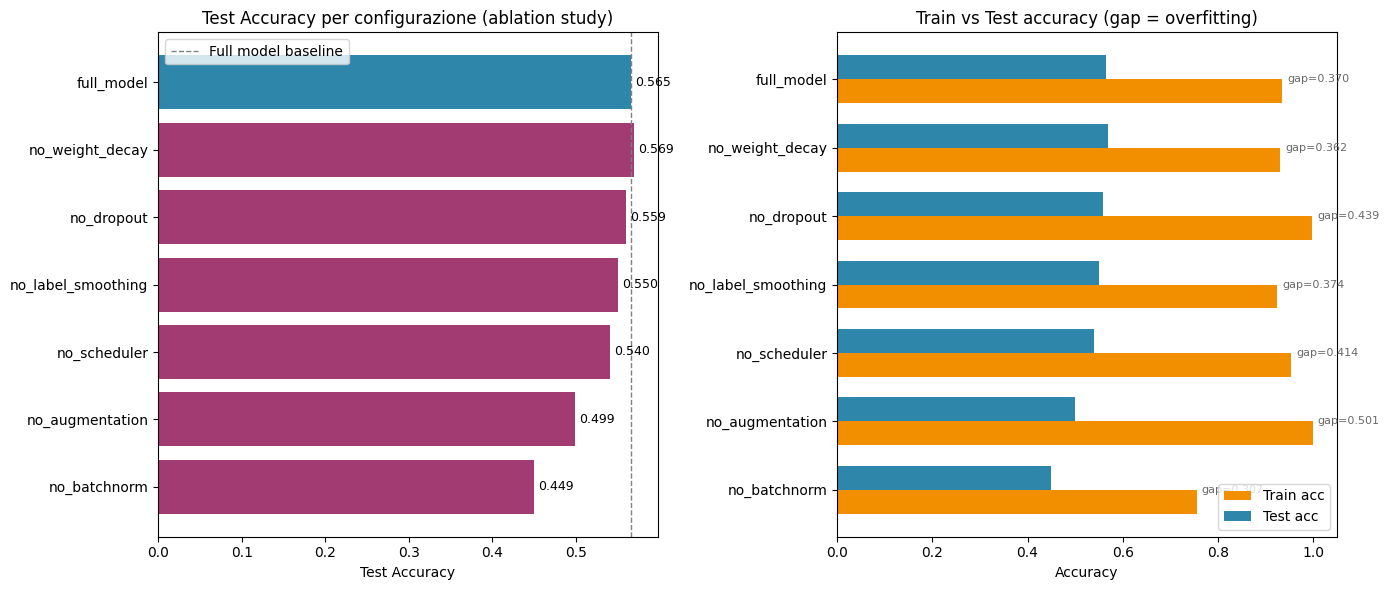

              name  test_acc  train_acc    gap  best_epoch
        full_model    0.5653     0.9353 0.3701          84
   no_weight_decay    0.5692     0.9312 0.3620          97
        no_dropout    0.5593     0.9985 0.4392          79
no_label_smoothing    0.5503     0.9246 0.3744          81
      no_scheduler    0.5404     0.9541 0.4137          89
   no_augmentation    0.4989     1.0000 0.5011          98
      no_batchnorm    0.4494     0.7563 0.3068          88


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.DataFrame(results)

# ordina mettendo full_model in cima, poi le altre per test_acc decrescente
df["is_full"] = df["name"] == "full_model"
df = df.sort_values(["is_full", "test_acc"], ascending=[False, False]).drop(columns="is_full")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#2E86AB" if n == "full_model" else "#A23B72" for n in df["name"]]

# --- Grafico 1: Test accuracy per configurazione ---
ax = axes[0]
bars = ax.barh(df["name"], df["test_acc"], color=colors)
ax.set_xlabel("Test Accuracy")
ax.set_title("Test Accuracy per configurazione (ablation study)")
ax.axvline(df.loc[df["name"] == "full_model", "test_acc"].values[0],
           color="gray", linestyle="--", linewidth=1, label="Full model baseline")
ax.legend()
ax.invert_yaxis()  # full_model in alto
for bar, val in zip(bars, df["test_acc"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", fontsize=9)

# --- Grafico 2: Train/Test accuracy affiancate + gap ---
ax = axes[1]
y = np.arange(len(df))
height = 0.35
ax.barh(y + height/2, df["train_acc"], height=height, label="Train acc", color="#F18F01")
ax.barh(y - height/2, df["test_acc"], height=height, label="Test acc", color="#2E86AB")
ax.set_yticks(y)
ax.set_yticklabels(df["name"])
ax.set_xlabel("Accuracy")
ax.set_title("Train vs Test accuracy (gap = overfitting)")
ax.invert_yaxis()
ax.legend()

# annota il gap accanto a ogni riga
for i, (train_a, gap) in enumerate(zip(df["train_acc"], df["gap"])):
    ax.text(train_a + 0.01, i, f"gap={gap:.3f}", va="center", fontsize=8, color="dimgray")

plt.tight_layout()
plt.savefig("ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Tabella riassuntiva ordinata ---
print(df[["name", "test_acc", "train_acc", "gap", "best_epoch"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

In [ ]:
def plot_training_curves(results, metric="val_acc", title=None):
    plt.figure(figsize=(10, 6))
    for r in results:
        epochs_range = range(len(r["history"][metric]))
        plt.plot(epochs_range, r["history"][metric], label=r["name"])
    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title or f"{metric} per epoca — confronto ablation")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"ablation_{metric}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_training_curves(results, metric="val_acc")
plot_training_curves(results, metric="train_acc")

In [ ]:
def plot_train_vs_val(result, title=None):
    h = result["history"]
    epochs_range = range(len(h["train_acc"]))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, h["train_acc"], label="Train acc")
    plt.plot(epochs_range, h["val_acc"], label="Val acc")
    plt.fill_between(epochs_range,
                      h["train_acc"], h["val_acc"],
                      alpha=0.15, color="red", label="Gap")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title or f"{result['name']}: train vs val accuracy nel tempo")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

full_model_result = next(r for r in results if r["name"] == "full_model")
plot_train_vs_val(full_model_result)

## Part 2

In [ ]:

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 100)
model = model.to(device)

In [ ]:
epochs = 60
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [ ]:
best_val_acc, best_params, best_epoch = train_loop(
    model, train_dl, epochs, optimizer, val_dl, scheduler=scheduler, verbose=True)

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 0: train loss 3.701 - train acc 0.168 - valid loss 3.353 - valid acc 0.223
Epoch 5: train loss 1.542 - train acc 0.756 - valid loss 2.389 - valid acc 0.497
Epoch 10: train loss 1.124 - train acc 0.914 - valid loss 2.205 - valid acc 0.593
Epoch 15: train loss 0.964 - train acc 0.975 - valid loss 2.010 - valid acc 0.647
Epoch 20: train loss 0.884 - train acc 0.992 - valid loss 1.842 - valid acc 0.695
Epoch 25: train loss 0.838 - train acc 0.998 - valid loss 1.759 - valid acc 0.722
Epoch 30: train loss 0.818 - train acc 1.000 - valid loss 1.679 - valid acc 0.755
Epoch 35: train loss 0.808 - train acc 1.000 - valid loss 1.662 - valid acc 0.756
Epoch 40: train loss 0.802 - train acc 1.000 - valid loss 1.656 - valid acc 0.758
Epoch 45: train loss 0.799 - train acc 1.000 - valid loss 1.650 - valid acc 0.769
Epoch 50: train loss 0.797 - train acc 1.000 - valid loss 1.648 - valid acc 0.771
Epoch 55: train loss 0.796 - train acc 1.000 - valid loss 1.643 - valid acc 0.770
Best epoch 47, bes

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
correct = total = 0
with torch.no_grad():
    for imgs, labels in test_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += ncorrect(model(imgs), labels).item()
        total += imgs.shape[0]
print(f"Test accuracy 2A: {correct/total:.4f}")

Test accuracy 2A: 0.7672
